In [1]:
%load_ext autoreload
%autoreload 2
from sdss_eval.evaluator import run_plot_parameter, create_tests
from sdss_eval.sqlparser import schema

k_to_test = {1: 1, 3:3, 5:5, 7:7,10:10 }
cols = [
            "specobj.z",
            "specobj.ra",
            "specobj.dec",
            "photoobj.ra",
            "photoobj.g",
            "photoobj.u"             
]
def tests(discretization_method):
    db = schema()
    db.create_bins(discretization_method=discretization_method, columns=cols)
    tests = []
    for k in k_to_test:
        add_tests = create_tests(algorithms= ["egreedy","thompson", "ucb", "pucb","popularRegion"], clause=3, top_k = k , db = db, th=500 )
        for test in add_tests: # add common
            test.update({
                'parameter_value': k
            })
        tests += add_tests
    return tests

CPU times: user 148 ms, sys: 41.1 ms, total: 189 ms
Wall time: 1min 25s


,Algorithm,1,3,5,7,10
0,Egreedy,0.47,0.61,0.70,0.73,0.76
1,UCB,0.52,0.71,0.78,0.81,0.84
2,pUCB,0.48,0.64,0.72,0.76,0.80
3,Thompson Sampling,0.48,0.65,0.74,0.77,0.81
4,Most popular,0.49,0.61,0.73,0.75,0.79


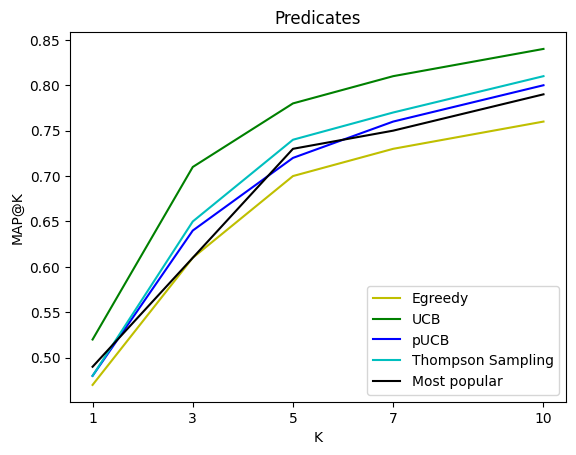

In [7]:
%%time
run_plot_parameter(tests("uniform"), parameter_name = "K", param_map = k_to_test).results

CPU times: user 108 ms, sys: 39.2 ms, total: 147 ms
Wall time: 1min 6s


,Algorithm,1,3,5,7,10
0,Egreedy,0.48,0.68,0.76,0.79,0.83
1,UCB,0.51,0.74,0.81,0.84,0.87
2,pUCB,0.51,0.73,0.79,0.82,0.84
3,Thompson Sampling,0.48,0.72,0.78,0.81,0.84
4,Most popular,0.46,0.71,0.78,0.80,0.81


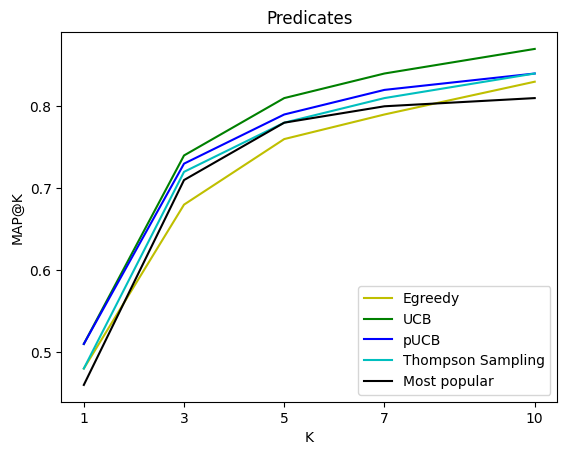

In [3]:
%%time
run_plot_parameter(tests("quantile"), parameter_name = "K", param_map = k_to_test).results

CPU times: user 124 ms, sys: 43.7 ms, total: 168 ms
Wall time: 1min 13s


,Algorithm,1,3,5,7,10
0,Egreedy,0.41,0.63,0.72,0.77,0.83
1,UCB,0.45,0.69,0.77,0.82,0.87
2,pUCB,0.46,0.70,0.78,0.82,0.86
3,Thompson Sampling,0.38,0.64,0.74,0.80,0.85
4,Most popular,0.38,0.59,0.66,0.79,0.84


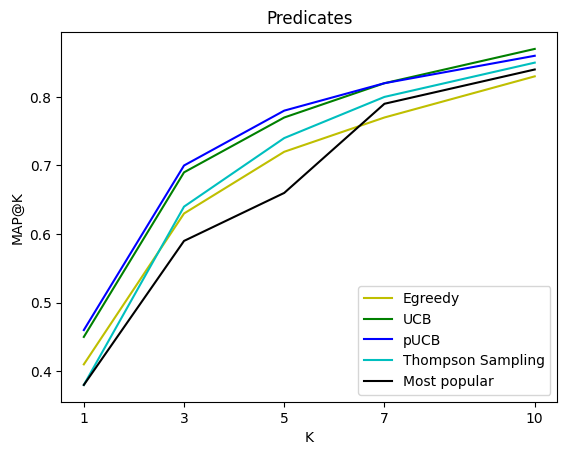

In [6]:
%%time
run_plot_parameter(tests("kmeans"), parameter_name = "K", param_map = k_to_test).results